# Reproduksi Tutorial Skforecast Explainability


Pada tugas ini dilakukan reproduksi terhadap tutorial Explainability yang terdapat pada dokumentasi resmi Skforecast:

https://skforecast.org/0.15.1/user_guides/explainability.html

Reproduksi dilakukan dengan menjalankan seluruh kode yang tersedia pada tutorial menggunakan Google Colab atau Jupyter Notebook lokal. Setiap tahapan analisis akan dijelaskan untuk memahami proses forecasting yang dilakukan, mulai dari pengolahan data, pembentukan model, proses prediksi, hingga interpretasi hasil menggunakan teknik explainability.

Selain menjalankan kode, tugas ini juga bertujuan untuk menganalisis bagaimana model melakukan prediksi, memahami bentuk data training yang digunakan, mempelajari konsep lag pada time series forecasting, serta menjelaskan proses analisis yang dilakukan pada studi kasus tersebut.

---

## Instalasi Library Skforecast

Pada tahap ini dilakukan instalasi library **Skforecast** yang akan digunakan untuk seluruh proses forecasting dan explainability pada tutorial ini. Perintah berikut digunakan untuk mengunduh dan memasang library beserta dependensi yang diperlukan agar seluruh kode pada tutorial dapat dijalankan dengan baik.


In [ ]:
!pip install skforecast

## Import Library

Pada tahap ini dilakukan import library yang diperlukan untuk proses analisis. Library yang digunakan mencakup pengolahan data (`pandas`), visualisasi (`matplotlib`), explainability model (`shap`), analisis feature importance (`scikit-learn`), algoritma machine learning (`LightGBM`), pengambilan dataset (`fetch_dataset`), serta pembuatan model forecasting menggunakan `ForecasterRecursive` dari Skforecast.

In [ ]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Mengunduh Dataset

Pada tahap ini dilakukan pengambilan dataset yang akan digunakan dalam proses forecasting. Dataset tersebut berisi data permintaan listrik dan temperatur yang nantinya digunakan sebagai dasar pelatihan model serta analisis explainability. Selain itu, beberapa baris awal data ditampilkan untuk memastikan dataset berhasil dimuat dan untuk melihat gambaran umum struktur data yang digunakan.

In [ ]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


## Agregasi Data Harian

Pada tahap ini dilakukan pengubahan data menjadi frekuensi harian agar lebih sesuai untuk proses forecasting. Nilai permintaan listrik diakumulasikan untuk setiap hari, sedangkan nilai temperatur dirata-ratakan sehingga setiap baris data merepresentasikan kondisi dalam satu hari. Setelah proses agregasi selesai, beberapa baris awal data ditampilkan untuk memastikan hasil transformasi telah sesuai.

In [ ]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


## Pembagian Data Training dan Testing

Pada tahap ini dataset dibagi menjadi dua bagian, yaitu data training dan data testing. Data training digunakan untuk melatih model agar dapat mempelajari pola yang terdapat pada data historis, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi pada data yang belum pernah dilihat sebelumnya. Pembagian ini penting untuk memastikan bahwa performa model dapat diukur secara objektif.

In [ ]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

## Pembuatan dan Pelatihan Model Forecasting

Pada tahap ini dibuat model forecasting menggunakan metode **ForecasterRecursive** dengan algoritma **LightGBM Regressor**. Model kemudian dilatih menggunakan data permintaan listrik sebagai target prediksi dan temperatur sebagai variabel pendukung. Selain itu, model memanfaatkan tujuh data historis sebelumnya (lag 1 hingga lag 7) untuk mempelajari pola perubahan permintaan listrik dari waktu ke waktu. Setelah proses pelatihan selesai, informasi mengenai konfigurasi model ditampilkan untuk memastikan model telah berhasil dibuat dan siap digunakan untuk analisis explainability.

In [ ]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 06:44:23 
Last fit date: 2026-06-10 06:44:24 
Skforecast version: 0.15.0 
Python version: 3.12.13 
Forecaster id: None

## Analisis Tingkat Kepentingan Fitur

Pada tahap ini dilakukan analisis tingkat kepentingan setiap fitur yang digunakan oleh model. Hasil yang ditampilkan menunjukkan seberapa besar kontribusi masing-masing lag dan variabel temperatur dalam proses prediksi permintaan listrik. Informasi ini membantu mengidentifikasi fitur yang paling berpengaruh terhadap keputusan model serta memberikan gambaran awal mengenai pola yang dipelajari selama proses pelatihan.

In [ ]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Membentuk Data Training untuk Model

Pada tahap ini dibentuk matriks data training yang digunakan oleh model selama proses pelatihan. Data time series yang sebelumnya berbentuk deret waktu diubah menjadi format supervised learning, di mana setiap baris berisi nilai-nilai historis (lag) dan variabel temperatur sebagai fitur input, serta nilai permintaan listrik pada periode berikutnya sebagai target. Setelah proses pembentukan selesai, beberapa baris pertama dari data input dan target ditampilkan untuk melihat struktur data yang sebenarnya digunakan oleh model.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## Membuat SHAP Explainer

Pada tahap ini dibuat objek SHAP Explainer untuk menganalisis bagaimana model menghasilkan prediksi. SHAP digunakan untuk mengukur kontribusi setiap fitur terhadap hasil prediksi yang dibuat oleh model. Setelah explainer dibuat, dilakukan perhitungan SHAP values untuk seluruh data training sehingga dapat diketahui seberapa besar pengaruh masing-masing lag dan temperatur dalam menentukan nilai prediksi permintaan listrik.

In [ ]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

## Visualisasi SHAP Feature Importance

Pada tahap ini dibuat visualisasi **SHAP Summary Plot** dalam bentuk diagram batang untuk melihat tingkat pengaruh setiap fitur terhadap prediksi model secara keseluruhan. Grafik ini menampilkan rata-rata nilai absolut SHAP dari masing-masing fitur, sehingga fitur dengan batang yang lebih panjang memiliki kontribusi yang lebih besar terhadap hasil prediksi. Melalui visualisasi ini dapat diketahui fitur mana yang paling sering digunakan model dalam menentukan nilai permintaan listrik dan seberapa besar pengaruh relatifnya dibandingkan fitur lainnya.

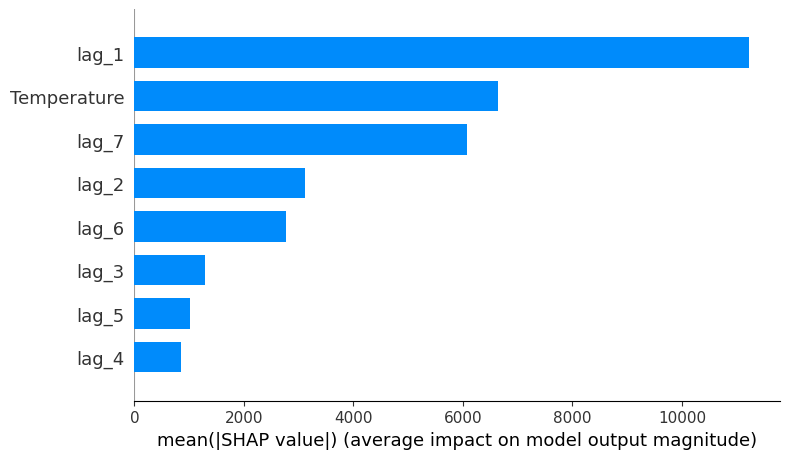

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

## Visualisasi Distribusi dan Pengaruh Fitur dengan SHAP

Pada tahap ini dibuat **SHAP Summary Plot** untuk melihat pengaruh setiap fitur terhadap prediksi model secara lebih detail. Berbeda dengan grafik sebelumnya yang hanya menampilkan tingkat kepentingan fitur, visualisasi ini juga menunjukkan arah pengaruh masing-masing fitur terhadap hasil prediksi. Setiap titik merepresentasikan satu observasi, sedangkan warna menunjukkan besar kecilnya nilai fitur. Melalui grafik ini dapat dianalisis bagaimana perubahan nilai lag maupun temperatur dapat meningkatkan atau menurunkan prediksi permintaan listrik yang dihasilkan model.

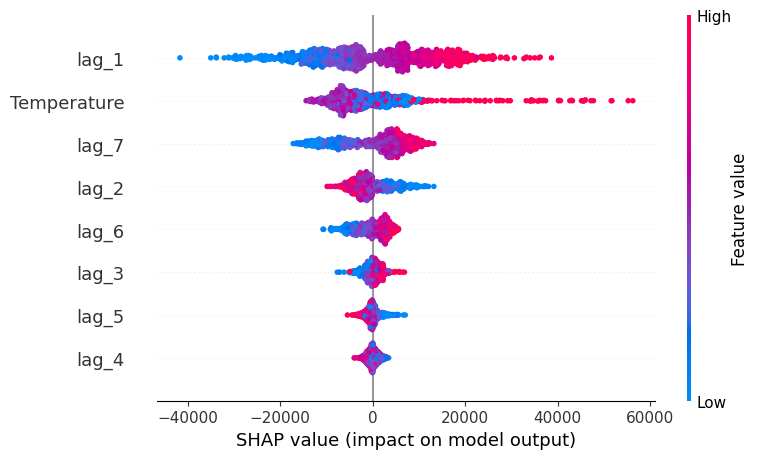

In [ ]:
shap.summary_plot(shap_values, X_train)

## Visualisasi Kontribusi Fitur pada Satu Prediksi

Pada tahap ini dibuat **SHAP Force Plot** untuk menganalisis bagaimana setiap fitur memengaruhi hasil prediksi pada satu observasi tertentu. Visualisasi ini menunjukkan kontribusi masing-masing fitur dalam mendorong nilai prediksi menjadi lebih tinggi atau lebih rendah dibandingkan nilai dasar (expected value) model. Dengan demikian, dapat diketahui faktor-faktor apa saja yang paling berperan dalam menghasilkan prediksi untuk observasi yang dipilih.

In [ ]:
# Force plot for the first observation
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

## Visualisasi Kontribusi Fitur pada Beberapa Observasi

Pada tahap ini dibuat **SHAP Force Plot** untuk 200 observasi pertama pada data training. Berbeda dengan force plot sebelumnya yang hanya menjelaskan satu prediksi, visualisasi ini memberikan gambaran bagaimana kontribusi setiap fitur berubah pada banyak observasi sekaligus. Melalui visualisasi ini dapat diamati pola pengaruh lag dan temperatur terhadap prediksi model pada berbagai kondisi data, sehingga membantu memahami perilaku model secara lebih menyeluruh.

In [ ]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

## Analisis Hubungan Fitur Temperature terhadap Prediksi

Pada tahap ini dibuat **SHAP Dependence Plot** untuk menganalisis hubungan antara nilai temperatur dan kontribusinya terhadap hasil prediksi model. Visualisasi ini membantu menunjukkan bagaimana perubahan nilai temperatur memengaruhi nilai SHAP, sehingga dapat diketahui apakah kenaikan atau penurunan temperatur cenderung meningkatkan atau menurunkan prediksi permintaan listrik. Selain itu, plot ini juga dapat digunakan untuk mengidentifikasi pola hubungan yang bersifat linier maupun nonlinier antara temperatur dan hasil prediksi model.

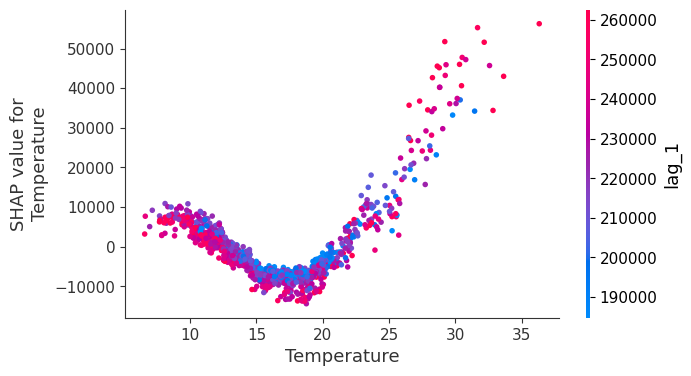

In [ ]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## Melakukan Prediksi

Pada tahap ini model yang telah dilatih digunakan untuk melakukan prediksi permintaan listrik pada 10 periode berikutnya. Proses prediksi memanfaatkan pola yang telah dipelajari dari data historis serta informasi temperatur pada data testing sebagai variabel pendukung. Hasil yang diperoleh berupa nilai prediksi permintaan listrik untuk setiap periode yang diperkirakan oleh model forecasting.

In [ ]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


## Membentuk Data Input untuk Prediksi

Pada tahap ini dibuat matriks input yang digunakan oleh model saat melakukan prediksi. Matriks tersebut berisi fitur-fitur yang dibutuhkan model, yaitu nilai historis permintaan listrik (lag) dan variabel temperatur untuk periode yang akan diprediksi. Dengan menampilkan matriks ini, dapat dilihat secara langsung data apa saja yang digunakan model sebagai dasar dalam menghasilkan prediksi pada langkah sebelumnya.

In [ ]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


## Analisis SHAP pada Hasil Prediksi Tertentu

Pada tahap ini dilakukan analisis explainability terhadap salah satu hasil prediksi yang telah dihasilkan model, yaitu prediksi pada tanggal yang dipilih. Nilai SHAP dihitung untuk data input prediksi, kemudian divisualisasikan menggunakan Force Plot untuk menunjukkan kontribusi masing-masing fitur terhadap hasil prediksi tersebut. Analisis ini membantu menjelaskan alasan model menghasilkan nilai prediksi tertentu dengan memperlihatkan fitur-fitur yang memberikan pengaruh positif maupun negatif terhadap prediksi akhir.

In [ ]:
# Force plot for a specific prediction
# ==============================================================================
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

## Analisis Kepentingan Fitur dengan Permutation Importance

Pada tahap ini dilakukan analisis kepentingan fitur menggunakan metode **Permutation Importance**. Metode ini bekerja dengan mengacak nilai suatu fitur, kemudian mengukur seberapa besar penurunan performa model yang terjadi. Jika performa model turun secara signifikan setelah suatu fitur diacak, maka fitur tersebut dianggap memiliki pengaruh yang besar terhadap prediksi. Hasil analisis ditampilkan dalam bentuk tabel yang menunjukkan tingkat kepentingan masing-masing lag dan variabel temperatur, sehingga dapat diketahui fitur mana yang paling berkontribusi dalam proses forecasting.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.regressor,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Analisis Pengaruh Fitur dengan Partial Dependence Plot

Pada tahap ini dibuat **Partial Dependence Plot (PDP)** untuk menganalisis bagaimana perubahan nilai suatu fitur memengaruhi hasil prediksi model. Visualisasi dilakukan pada fitur **Temperature** dan **lag_1** sehingga dapat diketahui hubungan antara kedua fitur tersebut dengan nilai prediksi permintaan listrik. Dengan pendekatan ini, pengaruh suatu fitur dapat diamati secara lebih jelas karena efek dari fitur lain dianggap tetap, sehingga membantu memahami pola yang dipelajari oleh model selama proses pelatihan.

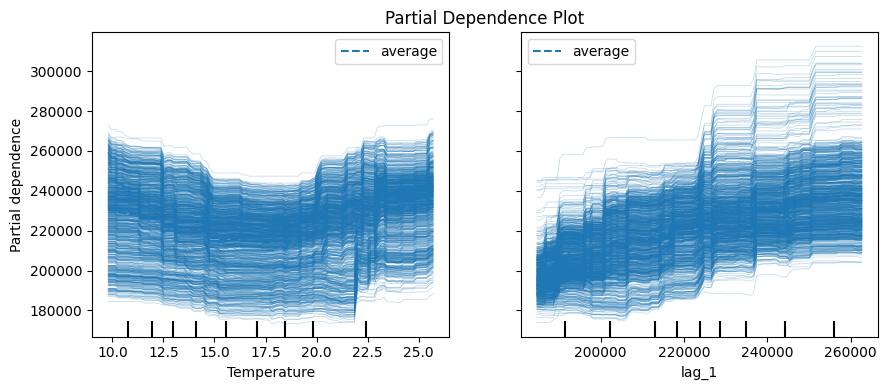

In [ ]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

## Soal dan Pembahasan

## Soal 1: Analisa Prediksi Tentang Apa?

Kasus ini melakukan prediksi deret waktu (time series forecasting) terhadap konsumsi obat-obatan (pharmaceutical drug sales) di Australia - khususnya data bulanan penjualan obat kelas H yang dipublikasikan oleh Australian Health Insurance Commission.

### Detail Prediksi:
- **Target variabel (output):** Nilai penjualan obat (monthly drug sales) dalam skala log/normal
- **Jenis forecasting:** Recursive / autoregresif - artinya model memprediksi 1 langkah ke depan secara berulang
- **Tujuan utama:** Tidak hanya memprediksi nilai masa depan, tetapi juga menjelaskan MENGAPA model membuat prediksi tersebut - yaitu fitur (lag) mana yang paling berpengaruh
- **Dataset:** h2o dari skforecast.datasets.fetch_dataset - data bulanan dari tahun 1991–2008

### Teknik Explainability yang Digunakan:
| Metode | Fungsi |
|---|---|
| **Feature Importance** (model-specific) | Melihat bobot fitur dari model LightGBM/RF secara langsung |
| **Permutation Importance** | Mengukur seberapa besar performa turun jika 1 fitur dikocok acak |
| **SHAP Values** | Menjelaskan kontribusi setiap fitur terhadap setiap prediksi individual |
| **Partial Dependence Plot (PDP)** | Memvisualisasikan hubungan rata-rata antara 1 fitur dengan output |


## Soal 2: Bentuk Data Training Input dan Output

### Konsep Kunci: Transformasi Time Series -> Supervised Learning

Skforecast mengubah data time series menjadi format supervised learning dengan cara membuat lag features (fitur lag):

| Kolom | Keterangan | Peran |
|---|---|---|
| lag_1 | Nilai penjualan 1 bulan lalu | **INPUT (X)** |
| lag_2 | Nilai penjualan 2 bulan lalu | **INPUT (X)** |
| lag_3 | Nilai penjualan 3 bulan lalu | **INPUT (X)** |
| ... | ... | ... |
| lag_k | Nilai penjualan k bulan lalu | **INPUT (X)** |
| y (nilai bulan ini) | Nilai penjualan bulan sekarang | **OUTPUT (y)** |

### Ilustrasi Transformasi:
```
Data asli time series:
  t=1: 0.50
  t=2: 0.55
  t=3: 0.53
  t=4: 0.60   <- target
  t=5: 0.58   <- target

Setelah transformasi (lags=3):
  X_train (input):         y_train (output):
  [lag_1, lag_2, lag_3]    [y]
  [0.53,  0.55,  0.50]  ->  0.60
  [0.60,  0.53,  0.55]  ->  0.58
```

> **Jadi:** Model regresi (LightGBM) belajar dari pola historis untuk memprediksi nilai berikutnya.

## Soal 3: Apa Itu Lag?

**Lag** adalah nilai variabel target dari waktu sebelumnya yang digunakan sebagai fitur (input) untuk memprediksi nilai saat ini.

### Definisi Formal:
$$\text{lag}_k = y_{t-k}$$

Contoh:
- lag_1 = nilai penjualan **1 bulan lalu** ($y_{t-1}$)
- lag_2 = nilai penjualan **2 bulan lalu** ($y_{t-2}$)
- lag_6 = nilai penjualan **6 bulan lalu** ($y_{t-6}$)

### Mengapa Lag Penting?

1. **Mengandung informasi historis** - pola masa lalu sering berulang (tren, musiman)
2. **Membuat model tahu konteks** - tanpa lag, model tidak tahu "posisi" sekarang dalam tren
3. **Autocorrelation** - dalam deret waktu, nilai sekarang biasanya berkorelasi kuat dengan nilai sebelumnya

### Dalam Konteks Explainability:
Lag yang paling berpengaruh terhadap prediksi dapat diidentifikasi melalui:
- **Feature importance** -> lag mana yang sering dipilih oleh pohon keputusan
- **SHAP values** -> lag mana yang mendorong prediksi naik/turun paling banyak
- **PDP** -> bagaimana hubungan lag tertentu dengan output

> Pada data penjualan obat bulanan, biasanya lag_1, lag_2, dan lag_12 (seasonality tahunan) memiliki pengaruh besar.

## Soal 4: Jelaskan Proses Analisis

Proses analisis pada kasus ini terdiri dari beberapa tahap sebagai berikut:

1. Mengunduh dan menyiapkan data yang berisi informasi Demand dan Temperature.

2. Melakukan agregasi data menjadi harian agar lebih sesuai untuk proses forecasting.

3. Membagi data menjadi training dan testing, sehingga model dapat dilatih dan diuji pada data yang berbeda.

4. Membangun dan melatih model forecasting menggunakan ForecasterRecursive dengan algoritma LightGBM dan 7 lag.

5. Membentuk matriks training (X_train dan y_train) yang berisi fitur lag, temperatur, dan target yang akan diprediksi.

6. Menganalisis Feature Importance untuk mengetahui fitur yang paling berpengaruh terhadap prediksi model.

7. Menganalisis SHAP Values menggunakan summary plot dan force plot untuk menjelaskan kontribusi setiap fitur terhadap hasil prediksi.

8. Melakukan prediksi pada data testing untuk memperkirakan nilai Demand pada periode berikutnya.

9. Menganalisis Permutation Importance untuk mengukur pentingnya setiap fitur berdasarkan perubahan performa model ketika fitur diacak.

10. Membuat Partial Dependence Plot (PDP) untuk melihat hubungan antara fitur tertentu (misalnya Temperature dan lag_1) dengan hasil prediksi.

11. Menarik kesimpulan mengenai fitur-fitur yang paling berpengaruh dan bagaimana model menghasilkan prediksi yang dibuat.

### Hasil Analisis

Berdasarkan hasil yang diperoleh, model berhasil memanfaatkan data historis dan temperatur untuk melakukan prediksi. Fitur lag memiliki pengaruh terbesar terhadap hasil forecasting, sedangkan metode explainability membantu menjelaskan alasan di balik prediksi yang dihasilkan model.

## Kesimpulan

Berdasarkan reproduksi notebook explainability pada Skforecast, dapat disimpulkan bahwa model forecasting mampu memprediksi nilai permintaan listrik menggunakan data historis (lag) dan temperatur sebagai variabel pendukung. Selain menghasilkan prediksi, berbagai metode explainability seperti Feature Importance, Permutation Importance, SHAP, dan Partial Dependence Plot berhasil digunakan untuk menjelaskan bagaimana model bekerja serta fitur-fitur yang paling berpengaruh terhadap hasil prediksi. Dengan demikian, analisis tidak hanya memberikan hasil forecasting, tetapi juga meningkatkan pemahaman dan transparansi terhadap keputusan yang dihasilkan oleh model.